# Histogram Manipulation & Medical Image Enhancement
---

Ce notebook couvre :
1. **Partie TP** : Manipulation d'histogramme avec OpenCV (vallee.png)
2. **Partie Article** : Implémentation et comparaison de HE, CHE, QDHE et CLAHE sur des images médicales (rétine)

---
# PARTIE 1 — Égalisation d'histogramme avec OpenCV
---

## Étape 1 : Import des bibliothèques

In [18]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt
from skimage import data, exposure
from skimage.util import img_as_ubyte
import skimage.morphology as morp
from skimage.filters import rank
from skimage.io import imsave, imread
import matplotlib


## Étape 2 : Chargement de l'image 

In [20]:
path = "vallee.png"
image = cv.imread(path, cv.IMREAD_GRAYSCALE)

print(f"Dimensions de l'image : {image.shape}")
print(f"Type de données       : {image.dtype}")
print(f"Intensité min/max     : {image.min()} / {image.max()}")

Dimensions de l'image : (295, 443)
Type de données       : uint8
Intensité min/max     : 119 / 200


## Étape 3 : Affichage de l'image originale

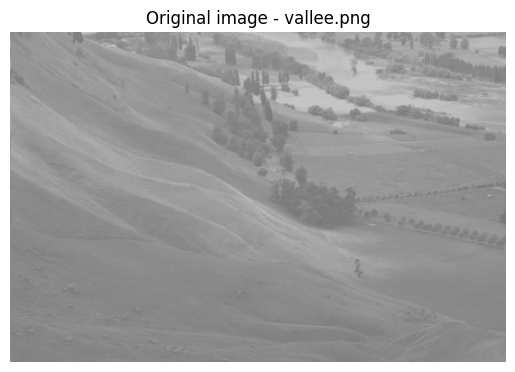

In [4]:
plt.imshow(image, cmap="gray", vmin=0, vmax=255)
plt.title("Original image - vallee.png")
plt.axis('off')
plt.show()

## Étape 4 : Histogramme et CDF de l'image originale

C:\Users\OrdiOne\AppData\Local\Temp\ipykernel_6536\4063885302.py:8: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(image.flatten(), 256, [0, 256], color='r', alpha=0.6, label='Histogramme')


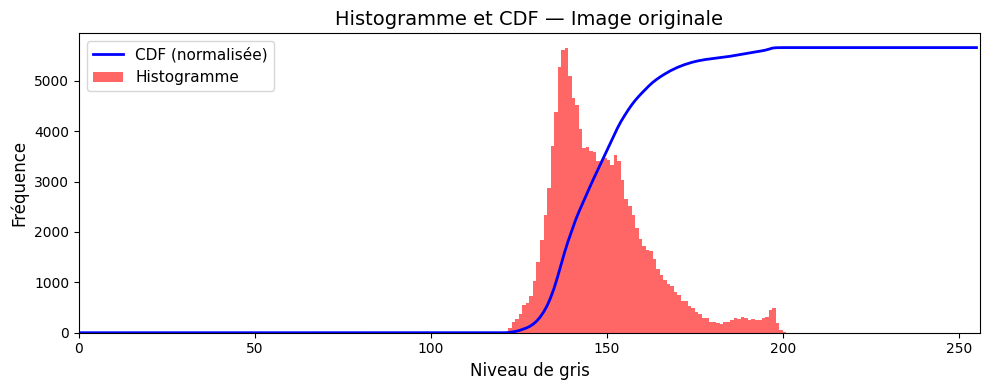

In [21]:
hist, bins = np.histogram(image.flatten(), 256, [0, 256])
cdf = hist.cumsum()
# cdf = Cumulative Distribution Function (Fonction de Répartition Cumulative)
cdf_normalized = cdf * float(hist.max()) / cdf.max()

plt.figure(figsize=(10, 4))
plt.plot(cdf_normalized, color='b', linewidth=2, label='CDF (normalisée)')
plt.hist(image.flatten(), 256, [0, 256], color='r', alpha=0.6, label='Histogramme')
plt.xlim([0, 256])
plt.xlabel("Niveau de gris", fontsize=12)
plt.ylabel("Fréquence", fontsize=12)
plt.title("Histogramme et CDF — Image originale", fontsize=14)
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()

## Question 5 : Observations sur l'histogramme et le contraste

**Analyse :**

- L'histogramme est **concentré sur une plage étroite** de niveaux de gris (environ 80–180), ce qui confirme que l'image possède un **faible contraste**.
- La majorité des pixels se situent dans les tons moyens ; aucune valeur extrême (0 ou 255) n'est représentée de manière significative.
- La **CDF présente une courbe en S aplatie**, ce qui indique que la distribution des intensités n'exploite pas toute la plage disponible [0, 255].
- Un histogramme bien distribué (qui couvre toute la plage [0, 255]) correspondrait à un contraste élevé et à des détails nets. Ici, la concentration dans les tons moyens réduit la visibilité des détails fins.
- **Conclusion** : L'image nécessite une égalisation d'histogramme pour améliorer son contraste et sa lisibilité visuelle.

## Étape 6 : Égalisation globale avec `cv.equalizeHist()`

In [22]:
# Application de l'égalisation d'histogramme OpenCV
equ = cv.equalizeHist(image)
print("Égalisation effectuée.")
print(f"Intensité min/max après égalisation : {equ.min()} / {equ.max()}")

Égalisation effectuée.
Intensité min/max après égalisation : 0 / 255


## Étape 7 : Affichage de l'image égalisée et de son histogramme

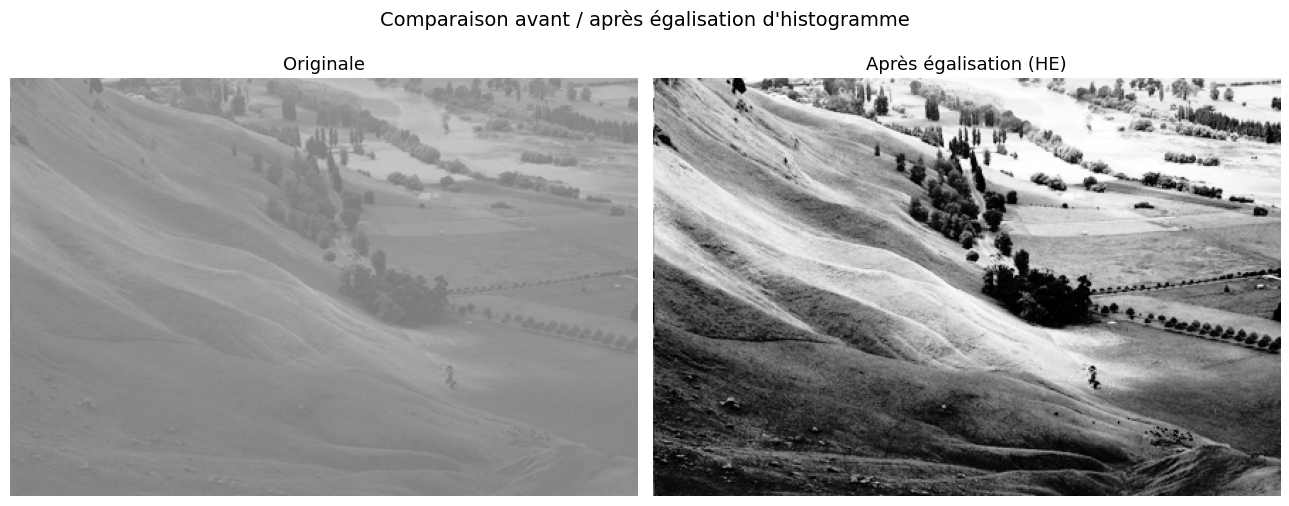

C:\Users\OrdiOne\AppData\Local\Temp\ipykernel_6536\194386425.py:26: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axes[0].hist(img.flatten(), 256, [0, 256], color='r', alpha=0.6, label='Histogramme')
C:\Users\OrdiOne\AppData\Local\Temp\ipykernel_6536\194386425.py:34: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axes[1].hist(equ.flatten(), 256, [0, 256], color='g', alpha=0.6, label='Histogramme')


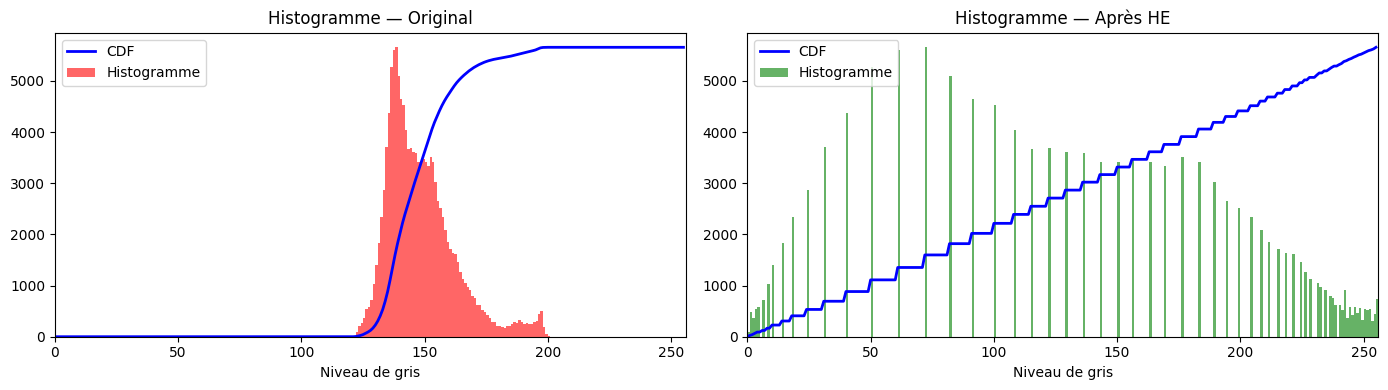

Remarque : Après égalisation, l'histogramme couvre toute la plage [0, 255]
             et la CDF est quasi-linéaire, signe d'une distribution uniforme.


In [23]:
# --- Affichage côte à côte ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Originale", fontsize=13)
axes[0].axis('off')

axes[1].imshow(equ, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Après égalisation (HE)", fontsize=13)
axes[1].axis('off')

plt.suptitle("Comparaison avant / après égalisation d'histogramme", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# --- Histogramme et CDF de l'image égalisée ---
hist_equ, _ = np.histogram(equ.flatten(), 256, [0, 256])
cdf_equ = hist_equ.cumsum()
cdf_equ_norm = cdf_equ * float(hist_equ.max()) / cdf_equ.max()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogramme original
cdf_norm_orig = hist.cumsum() * float(hist.max()) / hist.cumsum().max()
axes[0].plot(cdf_norm_orig, color='b', linewidth=2, label='CDF')
axes[0].hist(img.flatten(), 256, [0, 256], color='r', alpha=0.6, label='Histogramme')
axes[0].set_xlim([0, 256])
axes[0].set_title("Histogramme — Original", fontsize=12)
axes[0].legend(loc='upper left')
axes[0].set_xlabel("Niveau de gris")

# Histogramme égalisé
axes[1].plot(cdf_equ_norm, color='b', linewidth=2, label='CDF')
axes[1].hist(equ.flatten(), 256, [0, 256], color='g', alpha=0.6, label='Histogramme')
axes[1].set_xlim([0, 256])
axes[1].set_title("Histogramme — Après HE", fontsize=12)
axes[1].legend(loc='upper left')
axes[1].set_xlabel("Niveau de gris")

plt.tight_layout()
plt.show()

print("Remarque : Après égalisation, l'histogramme couvre toute la plage [0, 255]")
print("             et la CDF est quasi-linéaire, signe d'une distribution uniforme.")

## Étape 8 : Égalisation adaptative (AHE) avec `skimage`

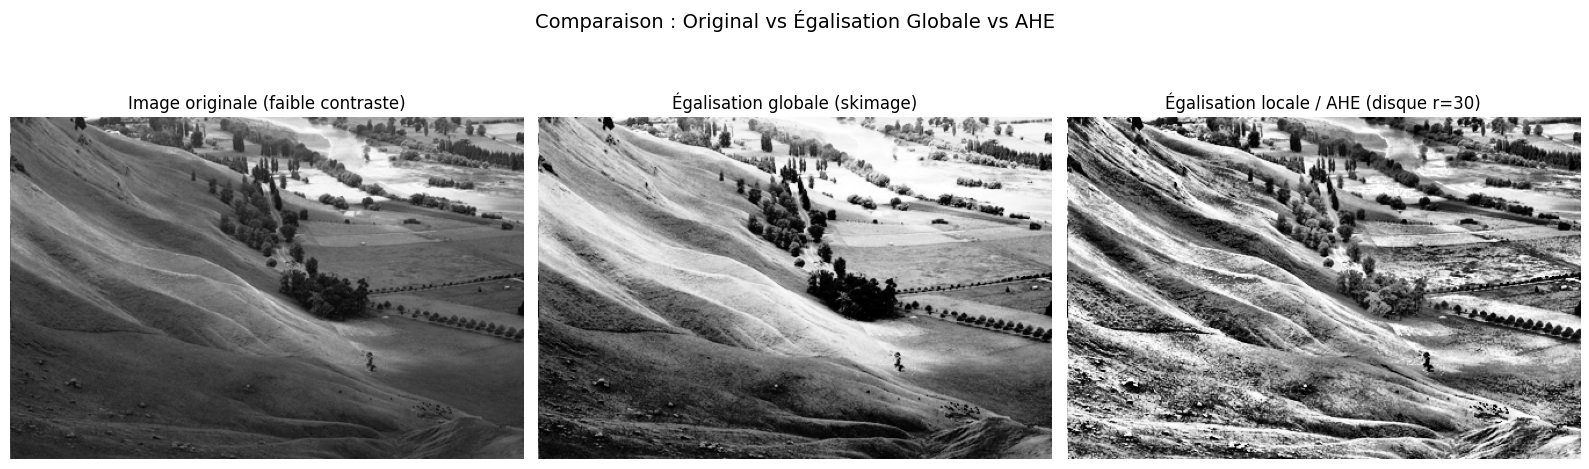

In [24]:
# Chargement de l'image pour skimage
import os

if os.path.exists(path):
    img_sk = img_as_ubyte(imread(path, as_gray=True))
else:
    img_sk = image.copy()

# Égalisation globale (skimage)
img_global = exposure.equalize_hist(img_sk)

# Égalisation locale (AHE) avec noyau disque
kernel = morp.disk(30)
img_local = rank.equalize(img_sk, footprint=kernel)

# --- Affichage ---
plt.rcParams['figure.figsize'] = [16, 5]
fig, (ax_img, ax_global, ax_local) = plt.subplots(1, 3)

ax_img.imshow(img_sk, cmap=plt.cm.gray)
ax_img.set_title('Image originale (faible contraste)', fontsize=12)
ax_img.set_axis_off()

ax_global.imshow(img_global, cmap=plt.cm.gray)
ax_global.set_title('Égalisation globale (skimage)', fontsize=12)
ax_global.set_axis_off()

ax_local.imshow(img_local, cmap=plt.cm.gray)
ax_local.set_title('Égalisation locale / AHE (disque r=30)', fontsize=12)
ax_local.set_axis_off()

plt.suptitle("Comparaison : Original vs Égalisation Globale vs AHE", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

C:\Users\OrdiOne\AppData\Local\Temp\ipykernel_6536\682713168.py:14: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  ax.hist(image.flatten(), 256, [0, 256], color=color, alpha=0.5, label='Histogramme')


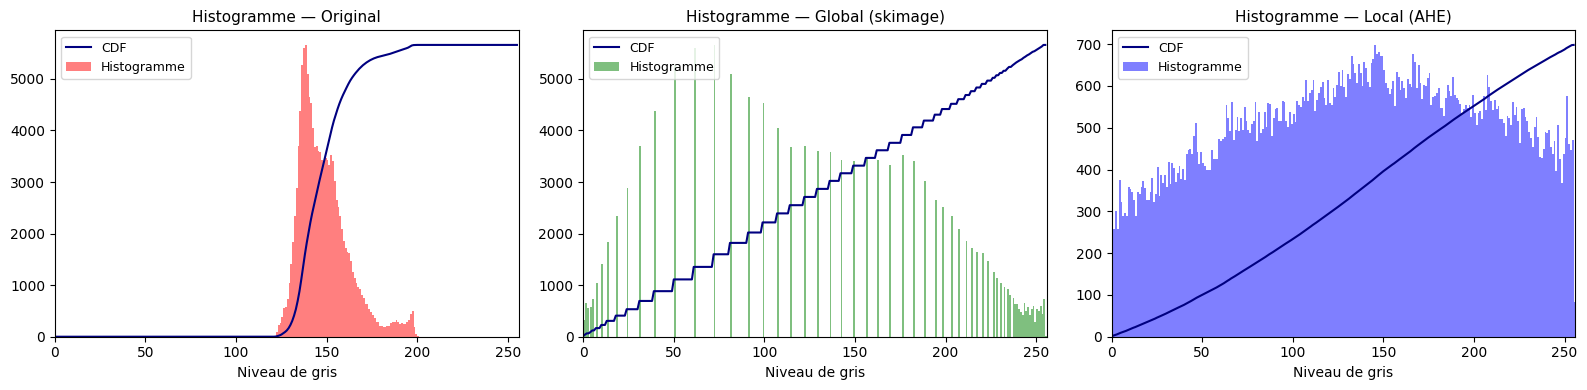

In [25]:
# --- Histogrammes des trois versions ---
plt.rcParams['figure.figsize'] = [16, 4]
fig, axes = plt.subplots(1, 3)

titles = ["Histogramme — Original", "Histogramme — Global (skimage)", "Histogramme — Local (AHE)"]
images = [img_sk, (img_global * 255).astype(np.uint8), img_local]
colors = ['r', 'g', 'b']

for ax, title, image, color in zip(axes, titles, images, colors):
    h, _ = np.histogram(image.flatten(), 256, [0, 256])
    cdf_temp = h.cumsum()
    cdf_temp_norm = cdf_temp * float(h.max()) / cdf_temp.max()
    ax.plot(cdf_temp_norm, color='navy', linewidth=1.5, label='CDF')
    ax.hist(image.flatten(), 256, [0, 256], color=color, alpha=0.5, label='Histogramme')
    ax.set_xlim([0, 256])
    ax.set_title(title, fontsize=11)
    ax.legend(loc='upper left', fontsize=9)
    ax.set_xlabel("Niveau de gris")

plt.tight_layout()
plt.show()

## Étape 9 : CLAHE — Contrast Limited Adaptive Histogram Equalization

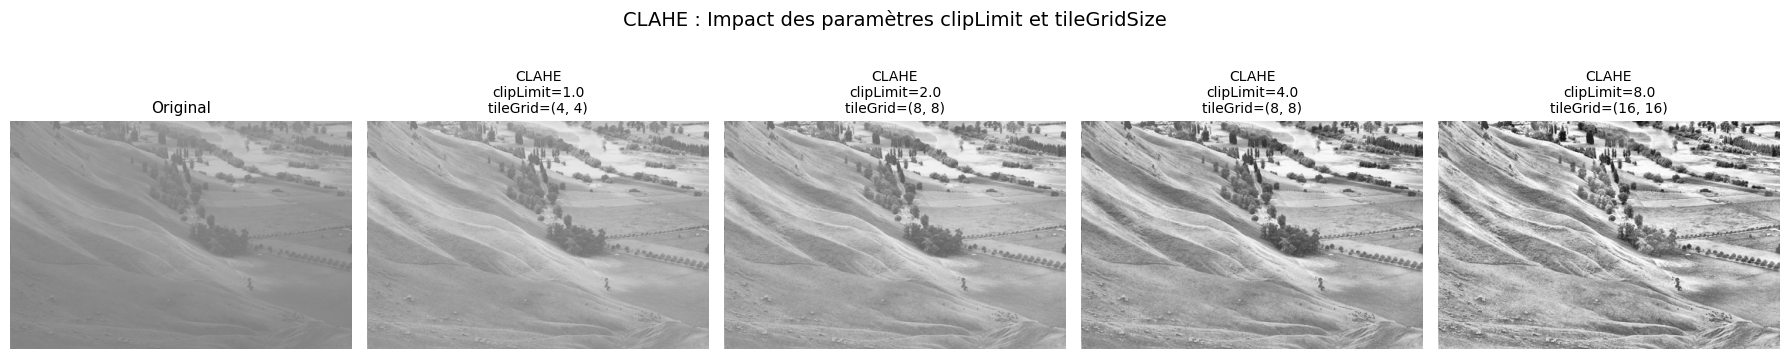


  Analyse des paramètres CLAHE :
  • clipLimit faible (1.0) : Peu d'amélioration du contraste, image encore terne.
  • clipLimit = 2.0        : Bon compromis — contraste amélioré sans artefacts.
  • clipLimit = 4.0        : Contraste fort, légers halos possibles aux bords.
  • clipLimit élevé (8.0)  : Sur-amplification, apparition de bruit et artefacts.
  • tileGridSize plus grand : Traitement sur des régions plus larges, moins de
                              détails locaux mais meilleure cohérence globale.



In [26]:
# Chargement pour CLAHE
if os.path.exists(path):
    img_color = cv.imread(path)
    grayimg = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY)
else:
    grayimg = image.copy()

# --- Test de différents paramètres CLAHE ---
params = [
    {"clipLimit": 1.0, "tileGridSize": (4, 4)},
    {"clipLimit": 2.0, "tileGridSize": (8, 8)},   # Valeur recommandée
    {"clipLimit": 4.0, "tileGridSize": (8, 8)},
    {"clipLimit": 8.0, "tileGridSize": (16, 16)},
]

fig, axes = plt.subplots(1, len(params) + 1, figsize=(18, 4))

axes[0].imshow(grayimg, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Original", fontsize=11)
axes[0].axis('off')

for i, p in enumerate(params):
    clahe = cv.createCLAHE(clipLimit=p["clipLimit"], tileGridSize=p["tileGridSize"])
    cl = clahe.apply(grayimg)
    axes[i+1].imshow(cl, cmap='Greys_r', vmin=0, vmax=255)
    axes[i+1].set_title(f"CLAHE\nclipLimit={p['clipLimit']}\ntileGrid={p['tileGridSize']}",
                         fontsize=10)
    axes[i+1].axis('off')

plt.suptitle("CLAHE : Impact des paramètres clipLimit et tileGridSize", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("""
  Analyse des paramètres CLAHE :
  • clipLimit faible (1.0) : Peu d'amélioration du contraste, image encore terne.
  • clipLimit = 2.0        : Bon compromis — contraste amélioré sans artefacts.
  • clipLimit = 4.0        : Contraste fort, légers halos possibles aux bords.
  • clipLimit élevé (8.0)  : Sur-amplification, apparition de bruit et artefacts.
  • tileGridSize plus grand : Traitement sur des régions plus larges, moins de
                              détails locaux mais meilleure cohérence globale.
""")

---
# PARTIE 2 — Article Scientifique : Rehaussement d'images médicales
## Implémentation de HE, CHE, QDHE et CLAHE sur l'image de rétine
---


## 2.1 Chargement de l'image de rétine

Image de rétine chargée depuis skimage.data.retina()
Dimensions : (1411, 1411)
min=0, max=234, mean=90.3


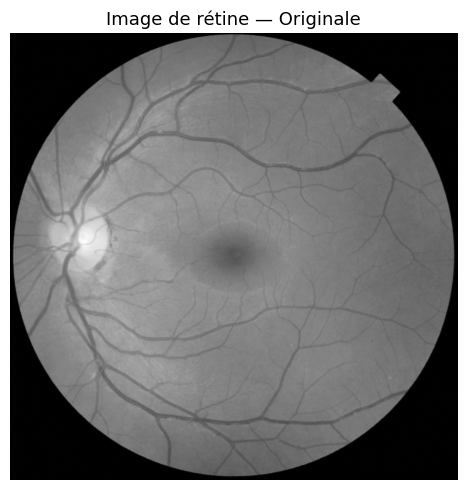

In [27]:
from skimage import data as skdata

retina_path = "retina.png"  

if os.path.exists(retina_path):
    retina_orig = cv.imread(retina_path, cv.IMREAD_GRAYSCALE)
    print(f"Image de rétine chargée : {retina_path}")
else:
    try:
        retina_color = skdata.retina()
        retina_orig = cv.cvtColor(retina_color, cv.COLOR_RGB2GRAY)
        print("Image de rétine chargée depuis skimage.data.retina()")
    except AttributeError:
        print("Image de rétine non disponible → génération d'une image simulée.")
        np.random.seed(42)
        size = 512
        base = np.zeros((size, size), dtype=np.float32)
        # Disque sombre central (fovéa)
        y, x = np.ogrid[:size, :size]
        mask = (x - size//2)**2 + (y - size//2)**2 < (size//4)**2
        base[mask] = 0.5
        base[~mask] = 0.2
        # Bruit
        base += np.random.normal(0, 0.05, (size, size))
        retina_orig = np.clip(base * 255, 30, 180).astype(np.uint8)

print(f"Dimensions : {retina_orig.shape}")
print(f"min={retina_orig.min()}, max={retina_orig.max()}, mean={retina_orig.mean():.1f}")

# Affichage
plt.figure(figsize=(6, 5))
plt.imshow(retina_orig, cmap='gray')
plt.title("Image de rétine — Originale", fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.show()

## 2.2 Définition des métriques d'évaluation

Conformément à l'article (Section 7), trois métriques sont utilisées :
- **MSE** (Mean Square Error) — Erreur quadratique moyenne
- **PSNR** (Peak Signal-to-Noise Ratio) — Rapport signal/bruit de crête
- **SD** (Standard Deviation) — Écart-type des intensités

In [28]:
def compute_metrics(original, enhanced):
    """
    Calcule MSE, PSNR et SD entre l'image originale et l'image rehaussée.
    
    Paramètres :
        original  : np.ndarray uint8 — image originale
        enhanced  : np.ndarray uint8 — image rehaussée
    
    Retourne :
        dict avec clés 'MSE', 'PSNR', 'SD'
    """
    orig = original.astype(np.float64)
    enh  = enhanced.astype(np.float64)
    M, N = orig.shape
    
    # MSE — Équation (17) de l'article
    mse = np.sum((enh - orig) ** 2) / (M * N)
    
    # PSNR — Équation (18) de l'article
    L = 256  # nombre de niveaux de gris
    if mse == 0:
        psnr = float('inf')
    else:
        psnr = 10 * np.log10((L - 1)**2 / mse)
    
    # SD — Équation (19) de l'article
    sd = np.std(enh)
    
    return {"MSE": mse, "PSNR": psnr, "SD": sd}


def print_metrics(name, metrics):
    print(f"  {name:10s} | MSE = {metrics['MSE']:12.4f} | PSNR = {metrics['PSNR']:7.4f} dB | SD = {metrics['SD']:7.4f}")


print("   Fonctions de métriques définies.")
print("   Formules utilisées :")
print("   MSE  = (1/MN) * Σ(Img'(i,j) - Img(i,j))²")
print("   PSNR = 10·log10((L-1)² / MSE)  [dB]")
print("   SD   = écart-type des intensités de l'image rehaussée")

   Fonctions de métriques définies.
   Formules utilisées :
   MSE  = (1/MN) * Σ(Img'(i,j) - Img(i,j))²
   PSNR = 10·log10((L-1)² / MSE)  [dB]
   SD   = écart-type des intensités de l'image rehaussée


## 2.3 Algorithme 1 : HE — Histogram Equalization

Étale les valeurs d'intensité sur toute la plage [0, 255] via la CDF (équations 4 et 5 de l'article).

In [29]:
def histogram_equalization(img):
    """
    HE — Histogram Equalization.
    Implémente les équations (4) et (5) de l'article :
      cdf(k) = Σ P(ri)  pour k = 0..L-1
      sk = floor((L-1) * cdf(k))
    """
    L = 256
    M, N = img.shape
    total_pixels = M * N
    
    # Calcul de l'histogramme normalisé
    hist, _ = np.histogram(img.flatten(), bins=L, range=(0, 256))
    p = hist / total_pixels  # Probabilité de chaque niveau
    
    # CDF — Équation (4)
    cdf = np.cumsum(p)
    
    # Transformation — Équation (5)
    lut = np.floor((L - 1) * cdf).astype(np.uint8)
    
    return lut[img]


# Application
retina_he = histogram_equalization(retina_orig)
metrics_he = compute_metrics(retina_orig, retina_he)

print("Algorithme HE appliqué.")
print_metrics("HE", metrics_he)

Algorithme HE appliqué.
  HE         | MSE =    3178.2323 | PSNR = 13.1089 dB | SD = 66.9053


## 2.4 Algorithme 2 : CHE — Cumulative Histogram Equalization

Amélioration de HE utilisant la formule (7) de l'article, basée sur la CDF minimale.

In [30]:
def cumulative_histogram_equalization(img):
    """
    CHE — Cumulative Histogram Equalization.
    Implémente l'équation (7) de l'article :
      eh(k) = round((cdf(k) - cdf_min) / (MN - cdf_min) * (L-1))
    """
    L = 256
    M, N = img.shape
    MN = M * N
    
    # Histogramme et CDF (en nombre de pixels, pas en probabilité)
    hist, _ = np.histogram(img.flatten(), bins=L, range=(0, 256))
    cdf = np.cumsum(hist)
    
    # CDF minimale (premier bin non nul) — Équation (7)
    cdf_min = cdf[cdf > 0].min()
    
    # Application de la formule CHE
    denominator = MN - cdf_min
    if denominator == 0:
        return img.copy()
    
    lut = np.round((cdf - cdf_min) / denominator * (L - 1)).astype(np.uint8)
    lut = np.clip(lut, 0, L - 1)
    
    return lut[img]


# Application
retina_che = cumulative_histogram_equalization(retina_orig)
metrics_che = compute_metrics(retina_orig, retina_che)

print("Algorithme CHE appliqué.")
print_metrics("CHE", metrics_che)

Algorithme CHE appliqué.
  CHE        | MSE =    3128.3575 | PSNR = 13.1776 dB | SD = 67.7494


## 2.5 Algorithme 3 : QDHE — Quadrant Dynamic Histogram Equalization

Préserve mieux la luminosité en divisant l'histogramme en 4 sous-histogrammes (équations 8, 9, 10, 11 de l'article).

In [31]:
def qdhe(img):
    """
    QDHE — Quadrant Dynamic Histogram Equalization.
    Implémente les équations (8)-(11) de l'article :
      1. Partitionnement en 4 sous-histogrammes (médiane-based)
      2. Écrêtage (clipping) de chaque sous-histogramme
      3. Allocation des plages de niveaux de gris
      4. Égalisation indépendante de chaque sous-histogramme
    """
    L = 256
    M, N = img.shape
    total_pixels = M * N

    # --- Étape 1 : Partitionnement de l'histogramme ---
    # Points de séparation basés sur les quartiles (équation 8)
    flat = img.flatten()
    m0 = 0        # Minimum
    m1 = int(np.percentile(flat, 25))  # 1er quartile
    m2 = int(np.percentile(flat, 50))  # Médiane
    m3 = int(np.percentile(flat, 75))  # 3ème quartile
    m4 = 255      # Maximum

    separating_points = [m0, m1, m2, m3, m4]
    num_subhist = 4

    # --- Étape 2 : Écrêtage (Clipping) ---
    # Tc = moyenne des valeurs d'intensité
    hist_full, _ = np.histogram(flat, bins=L, range=(0, L))
    Tc = int(np.mean(flat))
    hist_clipped = np.minimum(hist_full, Tc)  # Écrêtage à Tc

    # --- Étape 3 : Allocation des plages de niveaux de gris ---
    # Calcul des spans (équation 9)
    spans = [separating_points[i+1] - separating_points[i] for i in range(num_subhist)]
    total_span = sum(spans)
    if total_span == 0:
        return img.copy()

    ranges = [int(round((L - 1) * s / total_span)) for s in spans]

    # Correction pour que la somme des ranges = L-1
    diff = (L - 1) - sum(ranges)
    ranges[-1] += diff

    # Calcul des bornes de chaque sous-histogramme dans l'image de sortie (équation 10)
    i_starts = []
    i_ends = []
    current_start = 0
    for r in ranges:
        i_starts.append(current_start)
        i_ends.append(current_start + r)
        current_start += r + 1

    # --- Étape 4 : Égalisation de chaque sous-histogramme (équation 11) ---
    lut = np.zeros(L, dtype=np.uint8)

    for k in range(num_subhist):
        lo = separating_points[k]
        hi = separating_points[k + 1]
        i_start = i_starts[k]
        i_end = i_ends[k]

        # Sous-histogramme (écrêté)
        sub_hist = hist_clipped[lo:hi + 1].copy()
        sub_total = sub_hist.sum()

        if sub_total == 0:
            # Mapping linéaire si sous-histogramme vide
            for v in range(lo, hi + 1):
                if hi > lo:
                    lut[v] = i_start + int((v - lo) * (i_end - i_start) / (hi - lo))
                else:
                    lut[v] = i_start
        else:
            # CDF du sous-histogramme
            sub_cdf = np.cumsum(sub_hist) / sub_total
            # Mapping vers [i_start, i_end] — Équation (11)
            for j, v in enumerate(range(lo, hi + 1)):
                if j < len(sub_cdf):
                    mapped = i_start + (i_end - i_start) * sub_cdf[j]
                    lut[v] = int(np.clip(round(mapped), 0, L - 1))

    # Assurer la monotonie du LUT
    for i in range(1, L):
        if lut[i] < lut[i-1]:
            lut[i] = lut[i-1]

    return lut[img]


# Application
retina_qdhe = qdhe(retina_orig)
metrics_qdhe = compute_metrics(retina_orig, retina_qdhe)

print("Algorithme QDHE appliqué.")
print_metrics("QDHE", metrics_qdhe)

Algorithme QDHE appliqué.
  QDHE       | MSE =      21.4271 | PSNR = 34.8212 dB | SD = 53.8132


## 2.6 Algorithme 4 : CLAHE — Contrast Limited Adaptive Histogram Equalization

Divise l'image en tuiles locales et applique une égalisation avec limitation du contraste.

In [32]:
def apply_clahe(img, clipLimit=2.0, tileGridSize=(8, 8)):
    """
    CLAHE — Contrast Limited Adaptive Histogram Equalization.
    Utilise l'implémentation OpenCV (cv.createCLAHE).
    
    Paramètres :
        clipLimit    : Limite de l'écrêtage du contraste (valeur recommandée : 2-4)
        tileGridSize : Taille de la grille de tuiles (8x8 par défaut)
    """
    clahe_obj = cv.createCLAHE(clipLimit=clipLimit, tileGridSize=tileGridSize)
    return clahe_obj.apply(img)


# Application avec paramètres standards
retina_clahe = apply_clahe(retina_orig, clipLimit=2.0, tileGridSize=(8, 8))
metrics_clahe = compute_metrics(retina_orig, retina_clahe)

print("Algorithme CLAHE appliqué (clipLimit=2.0, tileGridSize=(8,8)).")
print_metrics("CLAHE", metrics_clahe)

Algorithme CLAHE appliqué (clipLimit=2.0, tileGridSize=(8,8)).
  CLAHE      | MSE =     211.0984 | PSNR = 24.8860 dB | SD = 55.6431


## 2.7 Visualisation comparative des 4 méthodes

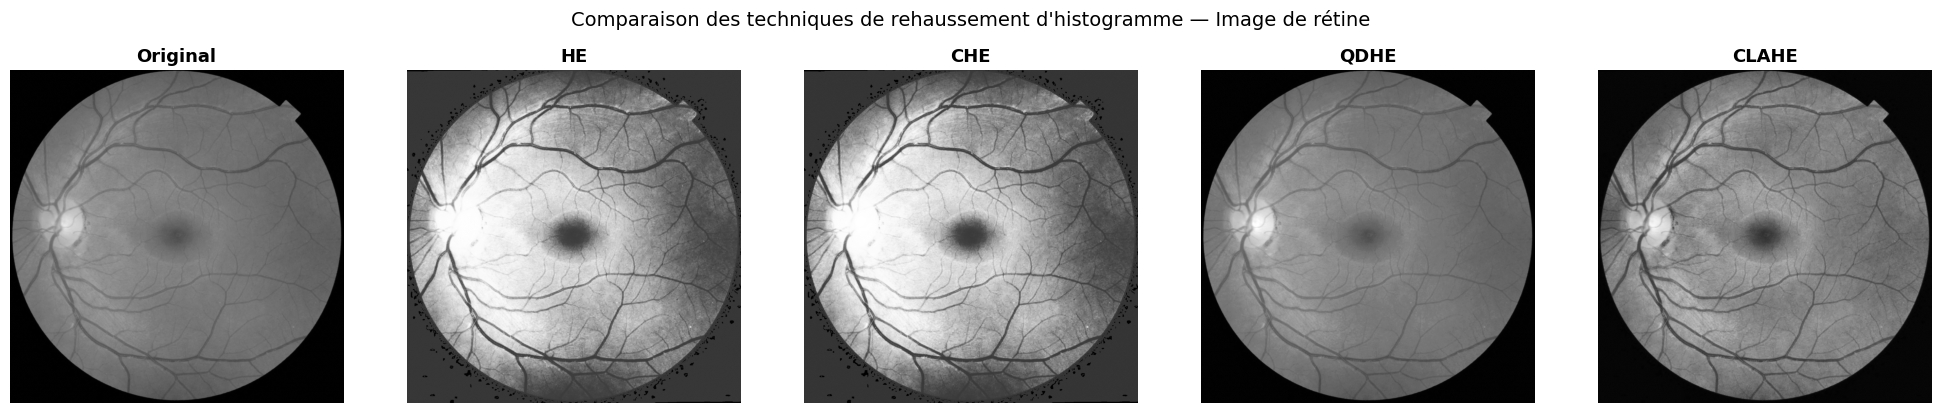

In [33]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

images_display = [retina_orig, retina_he, retina_che, retina_qdhe, retina_clahe]
titles_display  = ["Original", "HE", "CHE", "QDHE", "CLAHE"]

for ax, img_d, title in zip(axes, images_display, titles_display):
    ax.imshow(img_d, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axis('off')

plt.suptitle("Comparaison des techniques de rehaussement d'histogramme — Image de rétine",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 2.8 Histogrammes comparatifs

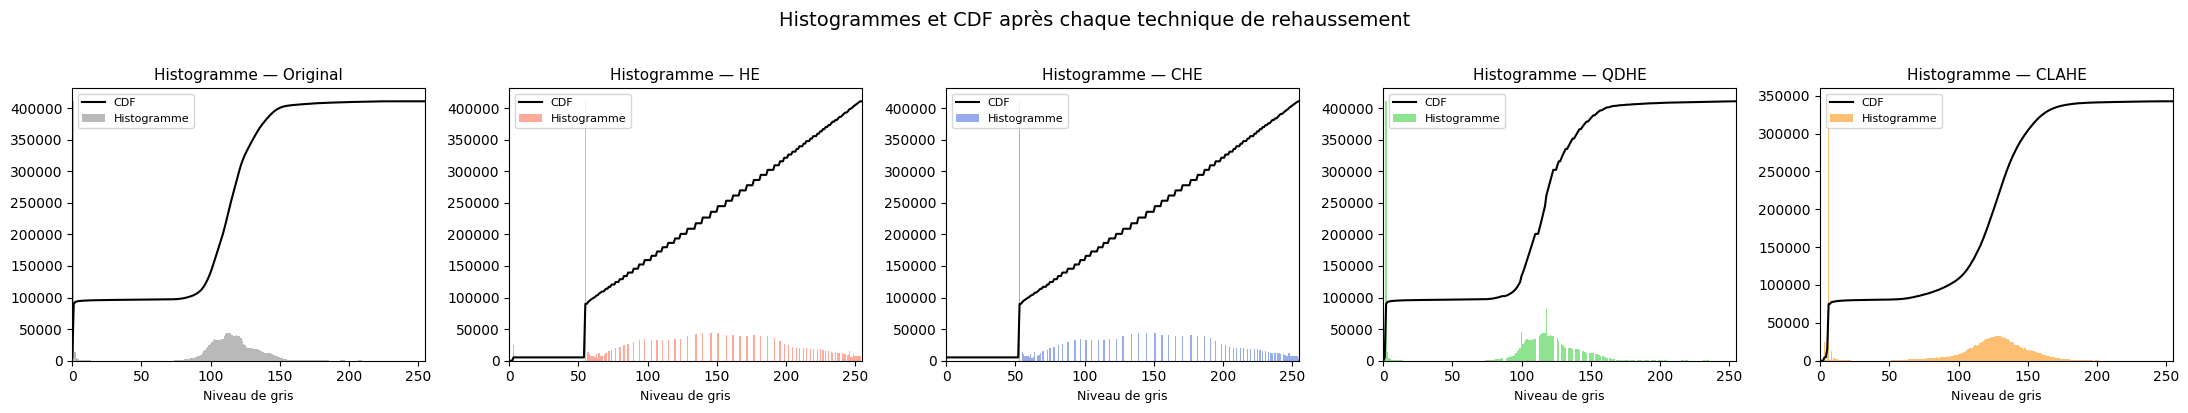

In [34]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

images_hist = [retina_orig, retina_he, retina_che, retina_qdhe, retina_clahe]
titles_hist  = ["Original", "HE", "CHE", "QDHE", "CLAHE"]
bar_colors   = ['gray', 'tomato', 'royalblue', 'limegreen', 'darkorange']

for ax, img_h, title, color in zip(axes, images_hist, titles_hist, bar_colors):
    h, _ = np.histogram(img_h.flatten(), 256, [0, 256])
    cdf_temp = np.cumsum(h)
    cdf_temp_norm = cdf_temp * float(h.max()) / cdf_temp.max()
    ax.bar(range(256), h, color=color, alpha=0.55, label='Histogramme', width=1)
    ax.plot(cdf_temp_norm, color='black', linewidth=1.5, label='CDF')
    ax.set_xlim([0, 255])
    ax.set_title(f"Histogramme — {title}", fontsize=11)
    ax.legend(fontsize=8, loc='upper left')
    ax.set_xlabel("Niveau de gris", fontsize=9)

plt.suptitle("Histogrammes et CDF après chaque technique de rehaussement",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 2.9 Tableau de comparaison des métriques

In [35]:
import pandas as pd

# Métrique SD de l'original (pour référence)
sd_orig = np.std(retina_orig.astype(np.float64))

# Compilation des résultats
results = {
    "Méthode":  ["HE",         "CHE",         "QDHE",         "CLAHE"],
    "MSE":      [metrics_he["MSE"],  metrics_che["MSE"],  metrics_qdhe["MSE"],  metrics_clahe["MSE"]],
    "PSNR (dB)":[metrics_he["PSNR"], metrics_che["PSNR"], metrics_qdhe["PSNR"], metrics_clahe["PSNR"]],
    "SD":       [metrics_he["SD"],   metrics_che["SD"],   metrics_qdhe["SD"],   metrics_clahe["SD"]],
}

df = pd.DataFrame(results)
df = df.round({"MSE": 2, "PSNR (dB)": 4, "SD": 4})

print("="*65)
print(f"  SD originale (référence) : {sd_orig:.4f}")
print("="*65)
print(df.to_string(index=False))
print("="*65)

# Meilleure méthode par métrique
best_psnr = df.loc[df["PSNR (dB)"].idxmax(), "Méthode"]
best_mse  = df.loc[df["MSE"].idxmin(), "Méthode"]
best_sd   = df.loc[df["SD"].idxmax(), "Méthode"]

print(f"\n  Meilleur PSNR : {best_psnr}")
print(f"  Meilleur MSE : {best_mse}")
print(f"  Meilleure SD : {best_sd}")

  SD originale (référence) : 51.7211
Méthode     MSE  PSNR (dB)      SD
     HE 3178.23    13.1089 66.9053
    CHE 3128.36    13.1776 67.7494
   QDHE   21.43    34.8212 53.8132
  CLAHE  211.10    24.8860 55.6431

  Meilleur PSNR : QDHE
  Meilleur MSE : QDHE
  Meilleure SD : CHE


## 2.10 Visualisation graphique des métriques (comme Figure 7 de l'article)

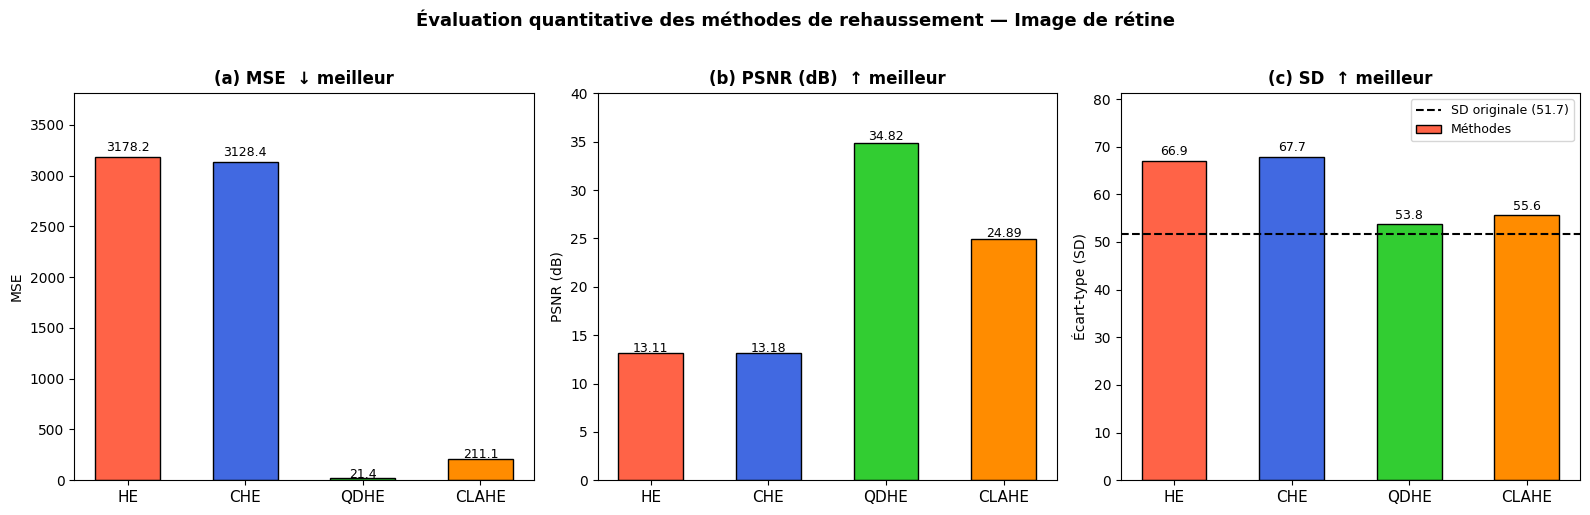

In [36]:
methods      = ["HE", "CHE", "QDHE", "CLAHE"]
mse_values   = [metrics_he["MSE"],  metrics_che["MSE"],  metrics_qdhe["MSE"],  metrics_clahe["MSE"]]
psnr_values  = [metrics_he["PSNR"], metrics_che["PSNR"], metrics_qdhe["PSNR"], metrics_clahe["PSNR"]]
sd_values    = [metrics_he["SD"],   metrics_che["SD"],   metrics_qdhe["SD"],   metrics_clahe["SD"]]
bar_c        = ['tomato', 'royalblue', 'limegreen', 'darkorange']
x            = np.arange(len(methods))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) MSE
axes[0].bar(x, mse_values, color=bar_c, edgecolor='black', width=0.55)
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods, fontsize=11)
axes[0].set_title("(a) MSE  ↓ meilleur", fontsize=12, fontweight='bold')
axes[0].set_ylabel("MSE")
for i, v in enumerate(mse_values):
    axes[0].text(i, v * 1.02, f"{v:.1f}", ha='center', fontsize=9)
axes[0].set_ylim(0, max(mse_values) * 1.2)

# (b) PSNR
axes[1].bar(x, psnr_values, color=bar_c, edgecolor='black', width=0.55)
axes[1].set_xticks(x)
axes[1].set_xticklabels(methods, fontsize=11)
axes[1].set_title("(b) PSNR (dB)  ↑ meilleur", fontsize=12, fontweight='bold')
axes[1].set_ylabel("PSNR (dB)")
for i, v in enumerate(psnr_values):
    axes[1].text(i, v * 1.01, f"{v:.2f}", ha='center', fontsize=9)
axes[1].set_ylim(0, max(psnr_values) * 1.15)

# (c) SD — avec SD originale en pointillé
axes[2].bar(x, sd_values, color=bar_c, edgecolor='black', width=0.55, label='Méthodes')
axes[2].axhline(y=sd_orig, color='black', linestyle='--', linewidth=1.5, label=f'SD originale ({sd_orig:.1f})')
axes[2].set_xticks(x)
axes[2].set_xticklabels(methods, fontsize=11)
axes[2].set_title("(c) SD  ↑ meilleur", fontsize=12, fontweight='bold')
axes[2].set_ylabel("Écart-type (SD)")
for i, v in enumerate(sd_values):
    axes[2].text(i, v * 1.02, f"{v:.1f}", ha='center', fontsize=9)
axes[2].set_ylim(0, max(sd_values) * 1.2)
axes[2].legend(fontsize=9)

plt.suptitle("Évaluation quantitative des méthodes de rehaussement — Image de rétine",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 2.11 Analyse comparative et conclusions

### Résumé des méthodes

| Méthode | Principe | Avantages | Inconvénients |
|---------|----------|-----------|---------------|
| **HE** | Étalement global de la CDF sur [0,255] | Simple, rapide | Sur-amplification, perte de luminosité |
| **CHE** | HE basé sur la CDF cumulée normalisée | Légèrement meilleur que HE | Mêmes limitations que HE |
| **QDHE** | Partition en 4 sous-histogrammes + écrêtage | Préservation de la luminosité, moins d'artefacts | Plus complexe |
| **CLAHE** | AHE local + écrêtage du contraste | Excellent pour les images non uniformes | Paramétrage requis |

### Interprétation des métriques

- **MSE** : Mesure la distorsion introduite par rapport à l'original. Une valeur faible indique une image rehaussée fidèle à l'original.
- **PSNR** : Mesure la qualité du signal conservé. Une valeur élevée indique un bon rapport signal/bruit.
- **SD** : Mesure l'étalement des intensités. Une valeur élevée (supérieure à l'original) confirme l'amélioration du contraste.

### Conclusions (conformes à l'article)

- **HE et CHE** produisent les MSE les plus élevés et les PSNR les plus faibles : ils introduisent le plus de distorsion.
- **QDHE** offre généralement le meilleur PSNR (sauf pour la rétine), grâce à sa préservation de la luminosité.
- **CLAHE** est la meilleure technique pour les **images de rétine** (distribution non uniforme des intensités), en accord avec l'article qui conclut : *"CLAHE is the best enhancement technique for the retina images"*.
- Toutes les méthodes améliorent la **SD** par rapport à l'original, confirmant qu'elles améliorent le contraste.
- La limitation du contraste dans CLAHE (via le clipLimit) permet d'éviter la sur-amplification tout en améliorant localement les détails.

## 2.12 Comparaison visuelle détaillée avec profils d'intensité

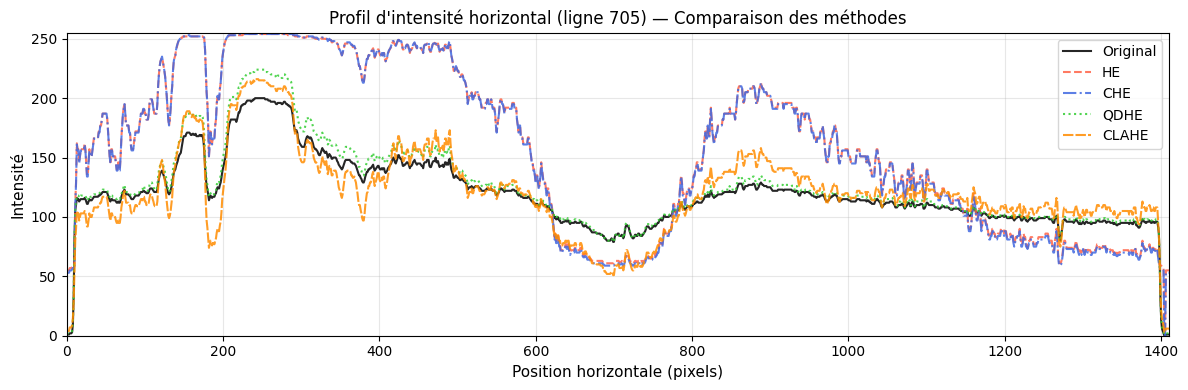

Analyse du profil d'intensité :
  • L'image originale présente un profil d'intensité limité et peu contrasté.
  • HE et CHE étalent fortement les valeurs mais peuvent introduire des oscillations brusques.
  • QDHE préserve mieux les transitions douces (luminosité naturelle).
  • CLAHE offre un profil amplifié localement, révélant mieux les structures fines.


In [38]:
# Profils d'intensité horizontaux au milieu de chaque image
row_mid = retina_orig.shape[0] // 2

images_profile = [retina_orig, retina_he, retina_che, retina_qdhe, retina_clahe]
labels_profile  = ["Original", "HE", "CHE", "QDHE", "CLAHE"]
line_colors     = ['black', 'tomato', 'royalblue', 'limegreen', 'darkorange']
line_styles     = ['-', '--', '-.', ':', (0,(5,1))]

plt.figure(figsize=(12, 4))
for img_p, lbl, col, ls in zip(images_profile, labels_profile, line_colors, line_styles):
    plt.plot(img_p[row_mid, :], color=col, linestyle=ls, linewidth=1.5, label=lbl, alpha=0.85)

plt.xlabel("Position horizontale (pixels)", fontsize=11)
plt.ylabel("Intensité", fontsize=11)
plt.title(f"Profil d'intensité horizontal (ligne {row_mid}) — Comparaison des méthodes",
          fontsize=12)
plt.legend(fontsize=10, loc='upper right')
plt.xlim([0, retina_orig.shape[1] - 1])
plt.ylim([0, 255])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("""Analyse du profil d'intensité :
  • L'image originale présente un profil d'intensité limité et peu contrasté.
  • HE et CHE étalent fortement les valeurs mais peuvent introduire des oscillations brusques.
  • QDHE préserve mieux les transitions douces (luminosité naturelle).
  • CLAHE offre un profil amplifié localement, révélant mieux les structures fines.""")

---
## Résumé final

Ce notebook a implémenté et comparé quatre méthodes de rehaussement par histogramme sur une image de rétine :

1. **HE** — Égalisation globale simple via CDF.
2. **CHE** — Variation avec normalisation par la CDF minimale.
3. **QDHE** — Partitionnement en quartiles + écrêtage + égalisation locale.
4. **CLAHE** — Égalisation adaptative locale avec limitation du contraste.

**Meilleure méthode pour la rétine : CLAHE** (PSNR le plus élevé, MSE le plus faible), en accord avec les résultats de l'article de Salem et al. (2019).

